
#PEMODELAN MACHINE LEARNING
##MODEL KLASIFIKASI

Prediksi Default atau kondisi gagal bayar Pinjaman



# **1. DATA UNDERSTANDING**

SUMBER DATA:

Dataset bersumber dari kaggle yaitu Credit_Risk_Analysis. dataset ini ini mencakup profil demografi dan keuangan nasabah yang mengajukan pinjaman yang digunakan untuk melatih model untuk  mengenali pola nasabah yang berpotensi gagal bayar. INFORMASI UMUM: Jumlah Data: 32,581. , Total kolom: 12 fitur dan jenis data: Numerik dan kategorikal.

FITUR DAN VARIABEL (TARGET):

menggunakan fitur AGE , INCOME , dan EMP_LENGTH untuk AMOUNT , RATE , dan CRED_LENGTH , PERCENT_INCOME, status kepemilikan rumah ( HOME ), INTENT, dan rekam jejak gagal bayar ( DEFAULT ) digunakan untuk memastikan tingkat kredibilitas nasabah secara menyeluruh sebelum sistem memberikan prediksi akhir

"Target yang diprediksi adalah Status , yaitu apakah nasabah mengalami gagal bayar ( 1 ) atau aman/bertahan ( 0 ). Karena target berupa kategori biner, maka permasalahan ini termasuk dalam klasifikasi ."


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

# Utils
from sklearn.base import clone

###**Load dataset**

In [2]:
df = pd.read_csv('credit_risk.csv')

### **Menampilkan 5 data teratas**

In [3]:
print("--- 5 Data Teratas ---")
display(df.head())

--- 5 Data Teratas ---


,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


In [ ]:
#Menampilkan jumlah data dan jumlah fitur awal
df.shape

(32581, 12)

### **Informasi tipe data dan Missing Values**

In [4]:
print("\n--- Informasi Dataset ---")
print(df.info())


--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              32581 non-null  int64  
 1   Age             32581 non-null  int64  
 2   Income          32581 non-null  int64  
 3   Home            32581 non-null  object 
 4   Emp_length      31686 non-null  float64
 5   Intent          32581 non-null  object 
 6   Amount          32581 non-null  int64  
 7   Rate            29465 non-null  float64
 8   Status          32581 non-null  int64  
 9   Percent_income  32581 non-null  float64
 10  Default         32581 non-null  object 
 11  Cred_length     32581 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 3.0+ MB
None


### **Statistik Deskriptif (Data Numerik)**

In [5]:
print("\n--- Statistik Deskriptif (Numerik) ---")
display(df.describe())


--- Statistik Deskriptif (Numerik) ---


,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,32581.000000,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,16290.006139,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,9405.479594,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,0.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,8145.000000,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,16290.000000,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,24435.000000,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,32780.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### **Statistik Deskriptif (Data Kategorikal)**

In [6]:
print("\n--- Statistik Deskriptif (Kategorikal) ---")
display(df.describe(include=['object']))


--- Statistik Deskriptif (Kategorikal) ---


,Home,Intent,Default
count,32581,32581,32581
unique,4,6,2
top,RENT,EDUCATION,N
freq,16446,6453,26836


In [7]:
#Memeriksa duplikat data
duplicates = df.duplicated().sum()
print(f"Jumlah duplikasi data: {duplicates}")

Jumlah duplikasi data: 0


### **Pengecekan Missing Value Awal**

In [8]:
print("\n--- Pengecekan Missing Value ---")
print(df.isnull().sum())


--- Pengecekan Missing Value ---
Id                   0
Age                  0
Income               0
Home                 0
Emp_length         895
Intent               0
Amount               0
Rate              3116
Status               0
Percent_income       0
Default              0
Cred_length          0
dtype: int64


# **2. DATA PREPROCESSING**

Pada tahap ini, data mentah diolah agar siap digunakan oleh pembelajaran mesin algoritma melalui beberapa langkah kunci:

Pembersihan Data & Outlie, Penanganan Missing Values, Pilihan Fitur: Kolom Id dihapus karena tidak memiliki nilai prediktif terhadap risiko kredit, Encoding Data Kategorikal serta Standardisasi Data. Hal ini sangat penting untuk menjaga konsistensi performa, terutama pada model yang sensitif terhadap perbedaan jarak nilai (seperti Gradient Boosting).

### **Encoding** **Data** **Kategorikal**
Mengubah data teks (Home, Intent, Default) menjadi angka menggunakan Label Encoding

In [10]:
le = LabelEncoder()

categorical_cols = ['Home', 'Intent', 'Default']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

### **Menghapus atau Menangani Outlier**
pada fitur Age dan Emp_length

In [11]:
df = df[df['Age'] < 100]
df = df[df['Emp_length'] < 100]

### **Mengatasi Missing Values: dengan Mendian**

In [12]:
df['Emp_length'] = df['Emp_length'].fillna(df['Emp_length'].median())
# Mengisi missing values pada 'Rate' dengan median
df['Rate'] = df['Rate'].fillna(df['Rate'].median())

### **Menghapus fitur tidak penting**

In [13]:
# Menghapus kolom 'Id' karena tidak memiliki nilai prediktif
df_clean = df.drop(columns=['Id'])

In [14]:
# Menampilkan data setelah dibersihkan
df_clean.shape

(31679, 11)

### **Standarisasi**

In [15]:
scaler = StandardScaler()
features = df_clean.drop(columns=['Status'])
target = df_clean['Status']

features_scaled = scaler.fit_transform(features)
features_final = pd.DataFrame(features_scaled, columns=features.columns)

### **Verifikasi Hasil DATA PREPROCESSING**

In [16]:
print("--- Info Data Setelah Preprocessing ---")
print(df_clean.info())
print("\n--- Pengecekan Missing Value Setelah Preprocessing ---")
print(df_clean.isnull().sum())
print("\n--- Tampilan 5 Data Teratas Setelah Encoding & Scaling ---")
display(features_final.head())

--- Info Data Setelah Preprocessing ---
<class 'pandas.core.frame.DataFrame'>
Index: 31679 entries, 1 to 32580
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             31679 non-null  int64  
 1   Income          31679 non-null  int64  
 2   Home            31679 non-null  int64  
 3   Emp_length      31679 non-null  float64
 4   Intent          31679 non-null  int64  
 5   Amount          31679 non-null  int64  
 6   Rate            31679 non-null  float64
 7   Status          31679 non-null  int64  
 8   Percent_income  31679 non-null  float64
 9   Default         31679 non-null  int64  
 10  Cred_length     31679 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 2.9 MB
None

--- Pengecekan Missing Value Setelah Preprocessing ---
Age               0
Income            0
Home              0
Emp_length        0
Intent            0
Amount            0
Rate              0
Status            0


,Age,Income,Home,Emp_length,Intent,Amount,Rate,Percent_income,Default,Cred_length
0,-1.083264,-1.078118,0.224687,0.054013,-0.885527,-1.367162,0.034226,-0.655048,-0.464799,-0.938311
1,-0.439486,-1.078118,-1.168924,-0.937341,0.270019,-0.656740,0.597715,3.767765,-0.464799,-0.691984
2,-0.761375,-0.018763,0.921493,-0.193826,0.270019,4.000473,1.366405,3.391355,-0.464799,-0.938311
3,-0.600431,-0.229118,0.921493,0.797529,0.270019,4.000473,1.053718,3.579560,2.151469,-0.445657
4,-1.083264,-1.072433,0.224687,-0.689503,1.425565,-1.130355,-1.268639,0.756488,-0.464799,-0.938311


## **3**. **EDA (VISUALISASI)**

### **Distribusi Target (Status)**
Terdapat masalah ketidakseimbangan datapada variabel target ( Status), di mana jumlah nasabah gagal bayar (kelas 1) jauh lebih sedikit dibandingkan nasabah lancar.

/tmp/ipykernel_1086/1710533869.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df_clean, palette='viridis')


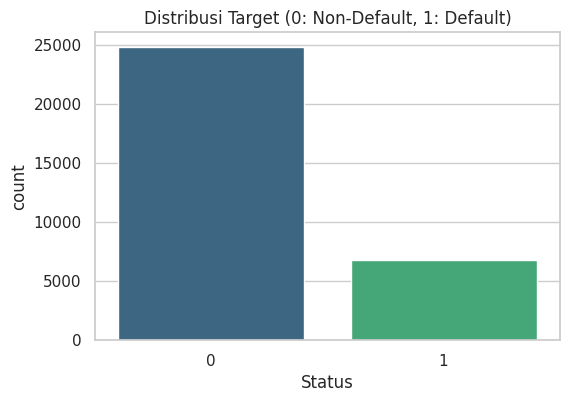

In [17]:
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='Status', data=df_clean, palette='viridis')
plt.title('Distribusi Target (0: Non-Default, 1: Default)')
plt.show()

### **Distribusi** **Fitur**

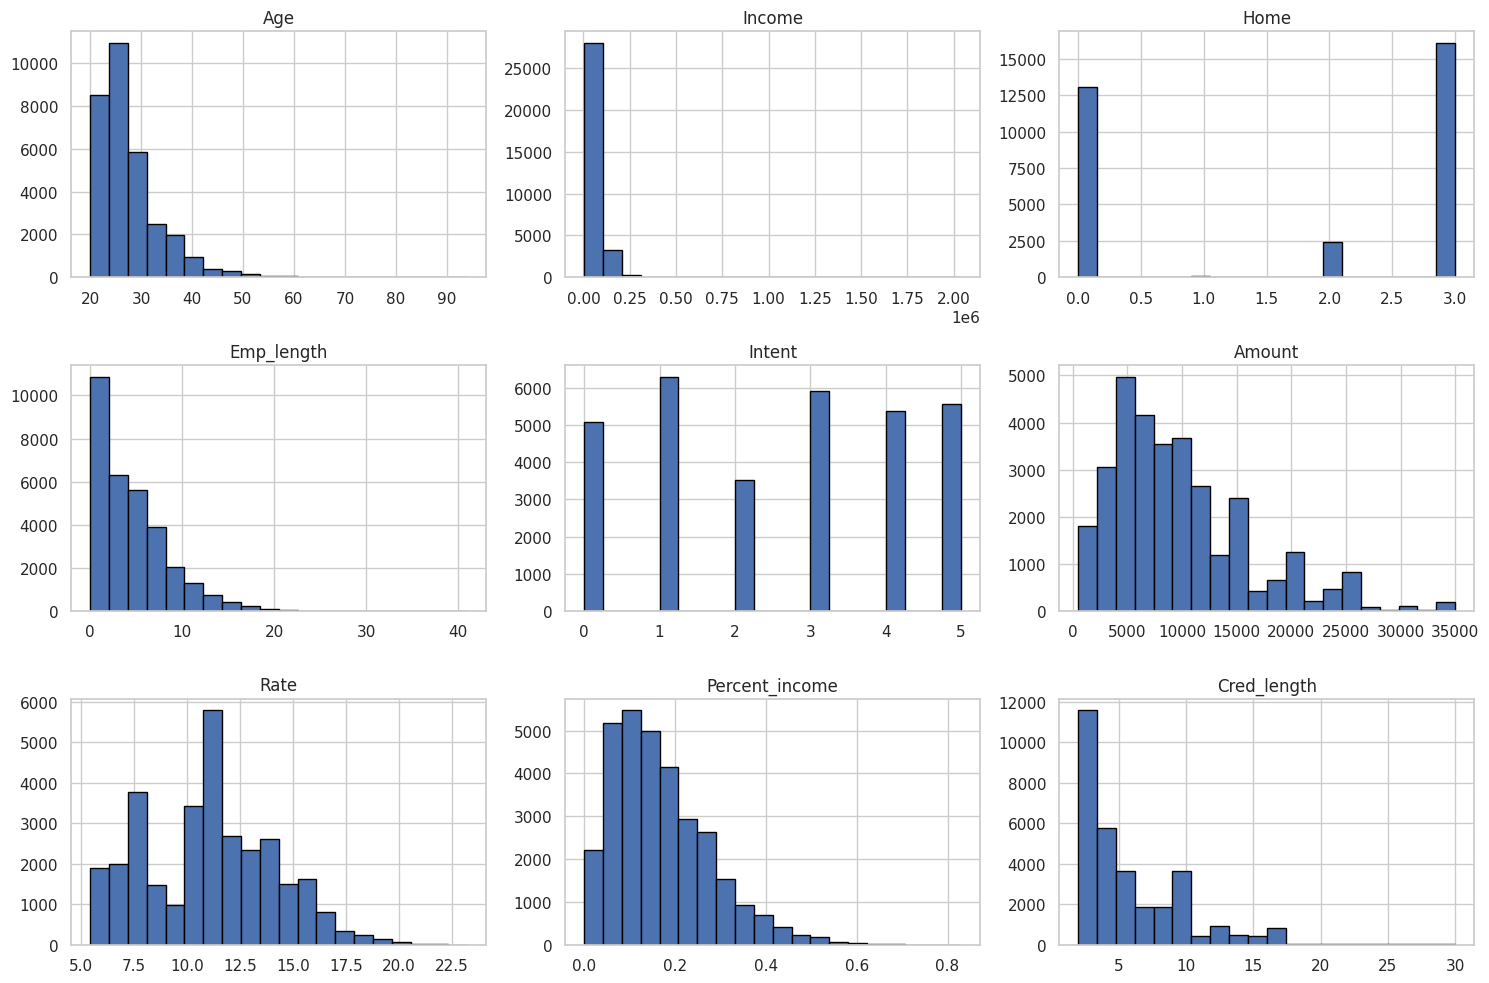

In [18]:
import matplotlib.pyplot as plt
features = ['Age', 'Income', 'Home', 'Emp_length', 'Intent', 'Amount', 'Rate', 'Percent_income', 'Cred_length']

df[features].hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

### **Heatmap Korelasi**

Hubungan Linear Kuat (0.88): Antara Usia ( Age ) dan Lama Kredit ( Cred_length ) , menunjukkan kematangan riwayat kredit seiring bertambahnya usia.

Pemicu Risiko Utama: Variabel Suku Bunga ( Rate ) (0.32) dan Persentase Pinjaman ( Percent_income ) (0.38) memiliki korelasi tertinggi terhadap status gagal bayar.

Faktor Mitigasi:  Pendapatan ( Pendapatan ) (-0.16) berdampak negatif terhadap kegagalan bayar; peningkatan pendapatan menurunkan risiko kredit nasaba


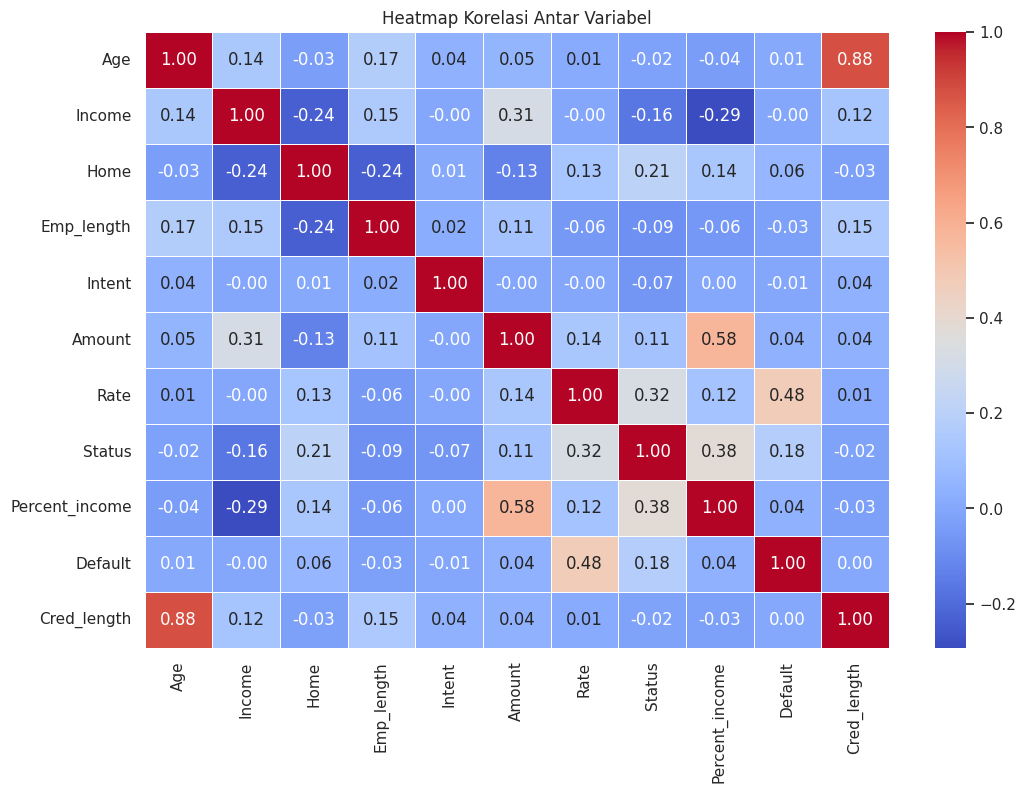

In [19]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

### **Boxplot: Loan Amount vs Status**
Grafik ini menunjukkan bahwa tetap mempertahankan outlier yang masuk akal (pinjaman besar) karena mereka membawa informasi penting tentang kegagalan pembayaran.

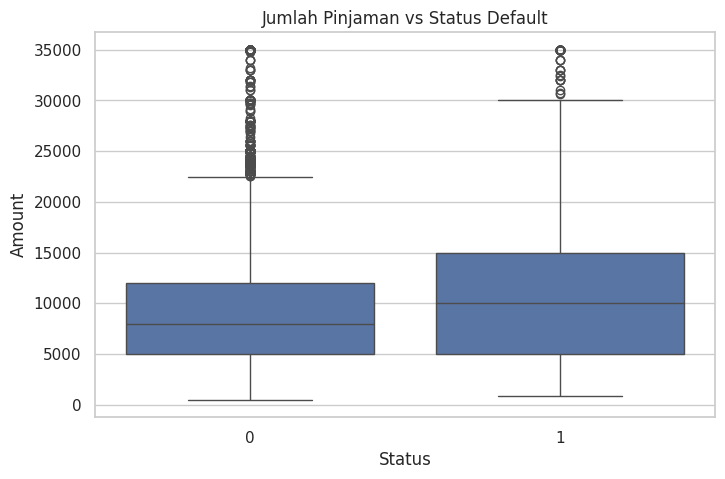

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Status', y='Amount', data=df_clean)
plt.title('Jumlah Pinjaman vs Status Default')
plt.show()

#**4. DATA SPLITTING**

### **Penentuan FEATURE & TARGET**
FITUR :menggunakan fitur AGE , INCOME , dan EMP_LENGTH untuk AMOUNT , RATE , dan CRED_LENGTH , PERCENT_INCOME, status kepemilikan rumah ( HOME ), INTENT, dan rekam jejak gagal bayar ( DEFAULT ) digunakan untuk memastikan tingkat kredibilitas nasabah secara menyeluruh sebelum sistem memberikan prediksi akhir

DAN VARIABEL (TARGET): "Target yang diprediksi adalah Status , yaitu apakah nasabah mengalami gagal bayar ( 1 ) atau aman/bertahan ( 0 ). Karena target berupa kategori biner, maka permasalahan ini termasuk dalam klasifikasi ."

In [21]:
X = df_clean.drop('Status', axis=1) # Gunakan df_clean, bukan df
y = df_clean['Status']


### **Data Splitting**
Pembagian data dengan 3 rasio yaitu:
70:30
80:20
90:10

In [22]:
from sklearn.model_selection import train_test_split

data_splits = {}

test_sizes = {
    "70:30": 0.30,
    "80:20": 0.20,
    "90:10": 0.10
}

for label, size in test_sizes.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=size, random_state=42, stratify=y
    )

    data_splits[label] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

--- Hasil Pembagian Data (Sebelum SMOTE) ---


## **SMOTE** + **Visualisasi**
Dikarenakan terjadi distribusi data yang tidak merata saya melakukan penanganan ketidakseimbangan data dengan teknik smote.
Smote tidak hanya menduplikasi data lama, tapi membuat data baru yang mirip dengan data asli dengan cara mencari titik tengah di antara data-data minoritas yang ada.
Smote Dilakukan setelah data splitting dan hanya pada data training untuk  menghindari data leakage



In [23]:
for label in data_splits:
    X_train = data_splits[label]['X_train']
    y_train = data_splits[label]['y_train']

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Update data training
    data_splits[label]['X_train'] = X_train_res
    data_splits[label]['y_train'] = y_train_res


/tmp/ipykernel_1086/3273347997.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette='viridis')


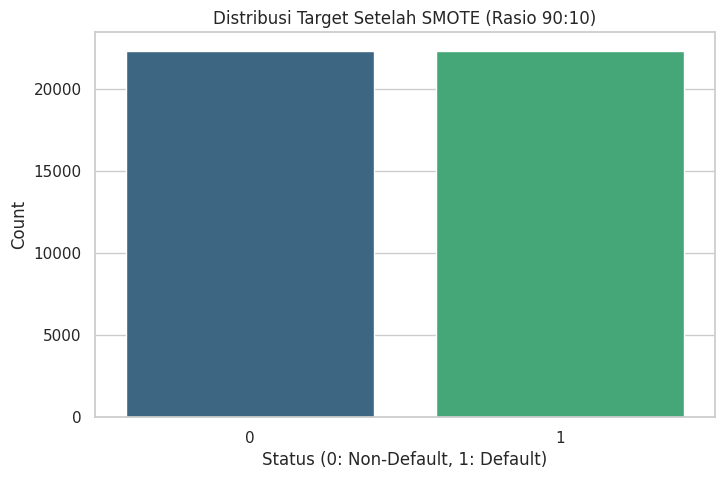

In [26]:
# rasio yang ingin ditampilkan, misalnya '90:10'
target_label = '90:10'
y_resampled = data_splits[target_label]['y_train']

plt.figure(figsize=(8, 5))
sns.countplot(x=y_resampled, palette='viridis')

plt.title(f'Distribusi Target Setelah SMOTE (Rasio {target_label})')
plt.xlabel('Status (0: Non-Default, 1: Default)')
plt.ylabel('Count')
plt.show()

# **5.** **MODEL BULDING  + HYPERPARAMETER**
Menggunakan 3 model berbeda yaitu MODEL LIGHTGBM, MODEL CATBOOST dan MODEL GRADIENT BOOSTING beserta hyperparameter tuningnya menggunakan GridSearchCV

### MODEL LIGHTGBM

In [27]:
# MODEL LIGHTGBM
print("--- Training LightGBM ---")
lgb_model = lgb.LGBMClassifier(random_state=42, verbosity=-1)

--- Training LightGBM ---


Tuning LightGBM

In [28]:
# Tuning LightGBM
lgb_tuning = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.05],
    'num_leaves': [20, 31],
    'max_depth': [5, 7, 10],
    'min_child_samples': [20, 50],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [0.1, 0.5]
}
grid_lgb = GridSearchCV(lgb.LGBMClassifier(random_state=42, verbosity=-1),
                        lgb_tuning, cv=3, scoring='accuracy', n_jobs=-1)
grid_lgb.fit(X_train_res, y_train_res)
best_lgb_final = grid_lgb.best_estimator_

print(f"Best LightGBM Params: {grid_lgb.best_params_}")

Best LightGBM Params: {'learning_rate': 0.05, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31, 'reg_alpha': 0.5, 'reg_lambda': 0.1}


### MODEL CATBOOST

In [29]:
#MODEL CATBOOST

print("--- Training CatBoost ---")
cat_model = CatBoostClassifier(silent=True, random_state=42)

--- Training CatBoost ---


Tuning CatBoost

In [33]:
#Tuning CatBoost

cat_tuning = {
    'iterations': [500, 1000],
    'learning_rate': [0.01, 0.03],
    'depth': [4, 6],
    'l2_leaf_reg': [10, 20, 30],
    'bootstrap_type': ['Bernoulli'],
    'subsample': [0.8],
}
grid_cat = GridSearchCV(CatBoostClassifier(silent=True, random_state=42),
                        cat_tuning, cv=3, scoring='recall', n_jobs=-1)
grid_cat.fit(X_train_res, y_train_res)
best_cat_final = grid_cat.best_estimator_


### MODEL GRADIENT BOOSTING

In [34]:
#MODEL GRADIENT BOOSTING
print("--- Training Gradient Boosting ---")
gb_model = GradientBoostingClassifier(random_state=42)

--- Training Gradient Boosting ---


Tuning Gradient Boosting

In [35]:
#Tuning Gradient Boosting
gb_tuning = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4],
    'subsample': [0.8, 0.9],
    'max_features': ['sqrt', 'log2']
}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       gb_tuning, cv=3, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train_res, y_train_res)

best_gb_final = grid_gb.best_estimator_

# **FUNGSI TRAIN**
Pada tahap ini, dilakukan proses pelatihan model menggunakan tiga algoritma utama— LightGBM, CatBoost, dan Gradient Boosting —yang diterapkan pada berbagai variasi rasio pembagian data ( 70:30, 80:20, dan 90:10 ). Setiap model dibor menggunakan data yang telah diseimbangkan melalui teknik SMOTE untuk memastikan prediksi tidak bias terhadap kelas mayoritas. Hasil dari proses ini, termasuk model yang telah dibor serta data train dan test terkait, disimpan ke dalam kamus terstruktur guna mempermudah tahap evaluasi dan perbandingan kinerja pada langkah berikutnya.

In [36]:
from sklearn.base import clone

# 1. Siapkan dictionary untuk menyimpan model yang sudah dilatih
trained_models = {}

# 2. Looping untuk setiap rasio
for rasio in ["70:30", "80:20", "90:10"]:

    # A. Ambil data (SUDAH hasil SMOTE dari tahap sebelumnya)
    X_train_bal = data_splits[rasio]['X_train']
    y_train_bal = data_splits[rasio]['y_train']
    X_test = data_splits[rasio]['X_test']
    y_test = data_splits[rasio]['y_test']

    # B. Clone model dari parameter terbaik
    model_gb = clone(best_gb_final)
    model_lgb = clone(best_lgb_final)
    model_cat = clone(best_cat_final)

    # C. Training
    model_gb.fit(X_train_bal, y_train_bal)
    model_lgb.fit(X_train_bal, y_train_bal)
    model_cat.fit(X_train_bal, y_train_bal, verbose=0)

    # D. Simpan hasil
    trained_models[rasio] = {
        "X_train": X_train_bal,
        "X_test": X_test,
        "y_train": y_train_bal,
        "y_test": y_test,
        "LightGBM": model_lgb,
        "CatBoost": model_cat,
        "Gradient Boosting": model_gb
    }

# **6. MODEL EVALUATION**
Tahap evaluasi model dilakukan untuk mengukur kinerja dan stabilitas algoritma melalui akurasi data pada pelatihan dan pengujian . Fungsi ini menghasilkan Laporan Klasifikasi yang mencakup nilai presisi, recall, dan f1-score , serta menghitung selisih (gap) akurasi untuk mendeteksi indikasi overfitting . Jika selisih akurasi berada di bawah 5% (0.05), model dinyatakan cukup stabil, namun jika lebih besar, sistem memberikan peringatan bahwa model terlalu menyesuaikan diri pada data latih dan berisiko kurang akurat saat menghadapi data nasabah baru.

In [40]:
def evaluate_model_lengkap(model, X_train, X_test, y_train, y_test, title, label):
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    selisih = abs(acc_train - acc_test)

    print(f"===== {title} =====")
    print(f"Accuracy Training: {acc_train:.4f}")
    print(f"Accuracy Testing : {acc_test:.4f}")
    print(f"Selisih (Gap)    : {selisih:.4f}")

    if selisih < 0.05:
        print("✅ Model cukup stabil")
    else:
        print("⚠️ Indikasi Overfitting")

    print("-" * 30)
    print(classification_report(y_test, y_pred_test))



## **MODEL EVALUASI Algoritma CatBoost**

In [42]:
# 1. EVALUASI CatBoost
model_name = "CatBoost"
print(f"EVALUASI MODEL: {model_name.upper()}\n" + "="*90)

output_columns = []

for label, data in trained_models.items():
    out = widgets.Output(layout=widgets.Layout(
        width='450px', margin='0 10px', border='1px solid #ddd', padding='10px'))

    with out:
        evaluate_model_lengkap(
            data[model_name], data["X_train"], data["X_test"],
            data["y_train"], data["y_test"],
            f"{model_name} {label}", label
        )

        plt.figure(figsize=(5, 3.5))
        y_pred = data[model_name].predict(data["X_test"])
        cm = confusion_matrix(data["y_test"], y_pred)

        warna = 'Blues'

        sns.heatmap(cm, annot=True, fmt='d', cmap=warna, cbar=False)
        plt.title(f"Confusion Matrix {label}")
        plt.xlabel("0                    1")
        plt.ylabel("0\n\n1")
        plt.tight_layout()
        plt.show()

    output_columns.append(out)

ui_box = widgets.HBox(output_columns)
display(ui_box)

EVALUASI MODEL: CATBOOST


## **MODEL EVALUASI Algoritma  LightGBM**

In [44]:
# 2. EVALUASI LightGBM
model_name = "LightGBM"
print(f"EVALUASI MODEL: {model_name.upper()}\n" + "="*90)

output_columns = []

for label, data in trained_models.items():
    out = widgets.Output(layout=widgets.Layout(
        width='450px', margin='0 10px', border='1px solid #ddd', padding='10px'))

    with out:
        evaluate_model_lengkap(
            data[model_name], data["X_train"], data["X_test"],
            data["y_train"], data["y_test"],
            f"{model_name} {label}", label
        )
        plt.figure(figsize=(5, 3.5))
        y_pred = data[model_name].predict(data["X_test"])
        cm = confusion_matrix(data["y_test"], y_pred)

        warna = 'Greens'
        sns.heatmap(cm, annot=True, fmt='d', cmap=warna, cbar=False)
        plt.title(f"Confusion Matrix {label}")
        plt.xlabel("0                    1")
        plt.ylabel("0\n\n1")
        plt.tight_layout()
        plt.show()

    output_columns.append(out)

ui_box = widgets.HBox(output_columns)
display(ui_box)

EVALUASI MODEL: LIGHTGBM


## **MODEL EVALUASI Algoritma Gradien Boosting**

In [56]:
# 3. EVALUASI Gradient Boosting
model_name = "Gradient Boosting"
print(f"EVALUASI MODEL: {model_name.upper()}\n" + "="*90)

output_columns = []

for label, data in trained_models.items():
    out = widgets.Output(layout=widgets.Layout(
        width='450px', margin='0 10px', border='1px solid #ddd', padding='10px'))

    with out:
        evaluate_model_lengkap(
            data[model_name], data["X_train"], data["X_test"],
            data["y_train"], data["y_test"],
            f"{model_name} {label}", label
        )

        # Tampilkan Confusion Matrix
        plt.figure(figsize=(5, 3.5))
        y_pred = data[model_name].predict(data["X_test"])
        cm = confusion_matrix(data["y_test"], y_pred)

        warna = 'Blues'

        sns.heatmap(cm, annot=True, fmt='d', cmap=warna, cbar=False)
        plt.title(f"Confusion Matrix {label}")
        plt.xlabel("0                    1")
        plt.ylabel("0\n\n1")
        plt.tight_layout()
        plt.show()

    output_columns.append(out)

ui_box = widgets.HBox(output_columns)
display(ui_box)

EVALUASI MODEL: GRADIENT BOOSTING


# **7. MODEL COMPARISION**
Membuat tabel atau grafik yang membandingkan:
Akurasi model,
Performa tiap algoritma, dan
Hasil dari setiap data splitting

## **Tabel Perbandingan Performa Model**
Hasil pengujian menunjukkan bahwa algoritma LightGBM dengan rasio split 90:10 adalah model paling optimal untuk prediksi risiko kredit ini. Model ini unggul dengan akurasi testing sebesar 92,65% dan nilai F1-Score 81%.
Dengan tingkat Recall 73%, model ini terbukti efektif dalam mendeteksi nasabah yang berisiko gagal bayar secara akurat. Selain itu, stabilitas model sangat baik karena selisih antara akurasi training (94,90%) dan testing sangat tipis, sehingga risiko overfitting dapat diminimalisir. Dibandingkan CatBoost dan Gradient Boosting, LightGBM memberikan keseimbangan terbaik antara akurasi dan kemampuan deteksi risiko.

In [57]:
results = []
for label, data in trained_models.items():
    for model_name in ["LightGBM", "CatBoost", "Gradient Boosting"]:
        model = data[model_name]
        y_pred = model.predict(data["X_test"])
        y_train_pred = model.predict(data["X_train"])

        results.append({
            'Model': model_name,
            'Split': label,
            'Train_Acc': round(accuracy_score(data["y_train"], y_train_pred), 4),
            'Test_Acc': round(accuracy_score(data["y_test"], y_pred), 4),
            'Precision': round(precision_score(data["y_test"], y_pred), 2),
            'Recall': round(recall_score(data["y_test"], y_pred), 2),
            'F1': round(f1_score(data["y_test"], y_pred), 2)
        })

# Buat DataFrame
df_results = pd.DataFrame(results)

print("--- Tabel Perbandingan Performa Model ---")
display(df_results.sort_values(by='Test_Acc', ascending=False).reset_index(drop=True))

--- Tabel Perbandingan Performa Model ---


,Model,Split,Train_Acc,Test_Acc,Precision,Recall,F1
0,LightGBM,90:10,0.9490,0.9265,0.91,0.73,0.81
1,CatBoost,90:10,0.9447,0.9252,0.92,0.71,0.80
2,CatBoost,80:20,0.9458,0.9222,0.91,0.70,0.80
3,LightGBM,80:20,0.9504,0.9216,0.90,0.72,0.80
4,CatBoost,70:30,0.9466,0.9213,0.90,0.71,0.80
5,LightGBM,70:30,0.9513,0.9201,0.89,0.72,0.80
6,Gradient Boosting,90:10,0.9191,0.9047,0.81,0.73,0.77
7,Gradient Boosting,80:20,0.9221,0.9015,0.79,0.73,0.76
8,Gradient Boosting,70:30,0.9238,0.8991,0.79,0.72,0.75


## **Visualisasi Perbandingan Akurasi**
Untuk analisis sistem risiko kredit kamu, LightGBM dengan rasio 90:10 adalah pilihan terbaik karena memberikan akurasi prediksi paling optimal.

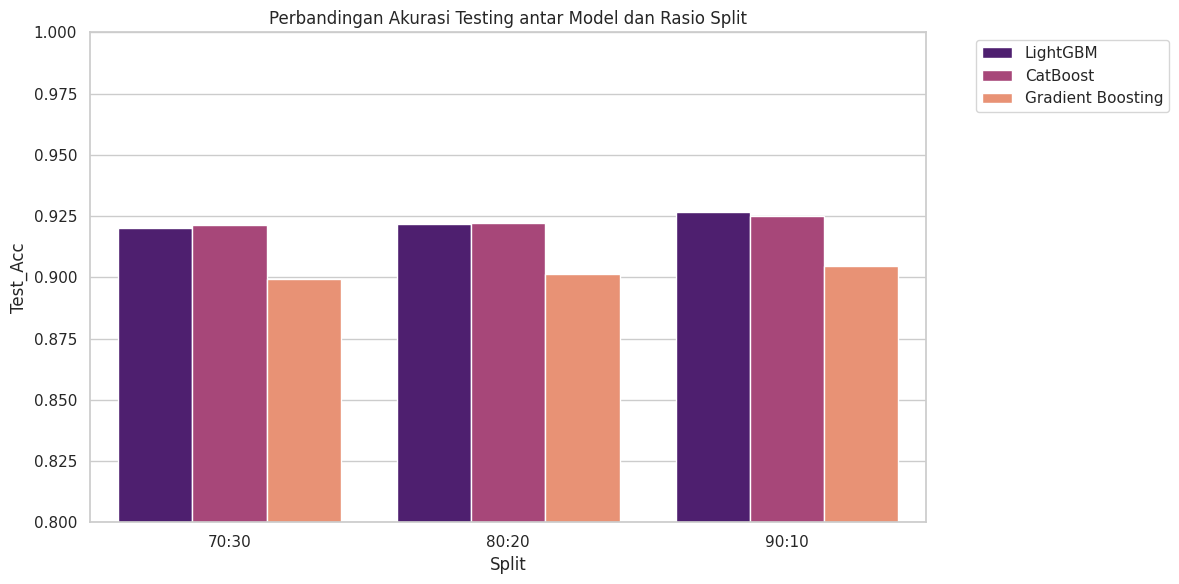

In [58]:
# Visualisasi Perbandingan Akurasi
plt.figure(figsize=(12, 6))
sns.barplot(x='Split', y='Test_Acc', hue='Model', data=df_results, palette='magma')
plt.title('Perbandingan Akurasi Testing antar Model dan Rasio Split')
plt.ylim(0.8, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Visualisasi** **Perbandingan** **F1-Score**
Model LightGBM (90:10) tetap menjadi rekomendasi utama karena memiliki keseimbangan terbaik dalam mendeteksi risiko secara akurat

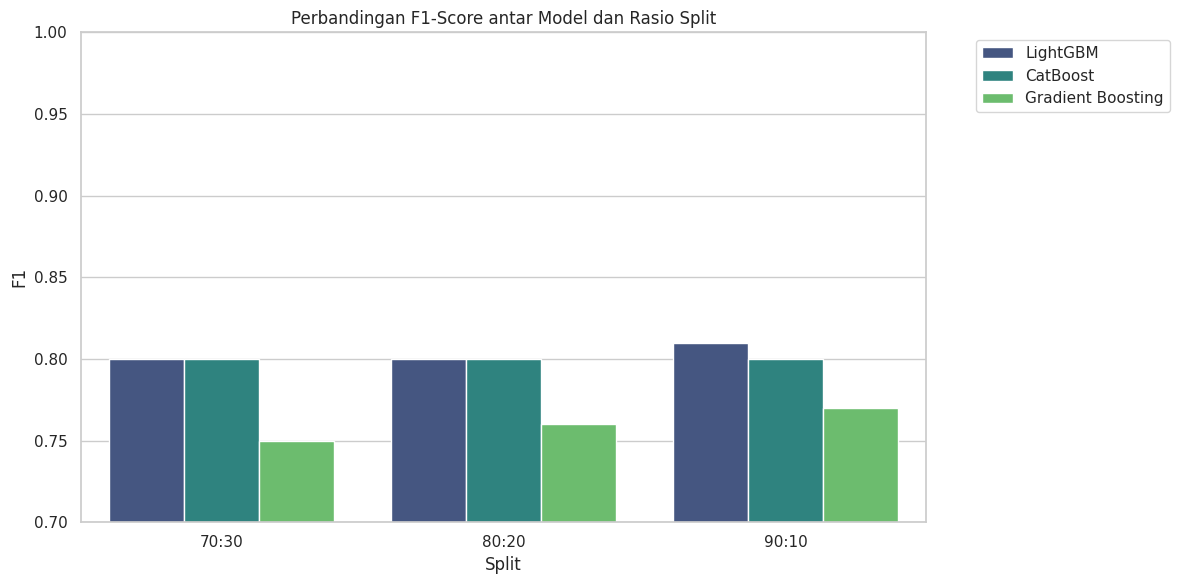

In [59]:
# Visualisasi Perbandingan F1-Score (Penting untuk Data Imbalanced/Credit Risk)
plt.figure(figsize=(12, 6))
sns.barplot(x='Split', y='F1', hue='Model', data=df_results, palette='viridis')
plt.title('Perbandingan F1-Score antar Model dan Rasio Split')
plt.ylim(0.7, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Analisis Gap Overfitting**

Meskipun LightGBM memiliki akurasi tertinggi, Gradient Boosting dan CatBoost adalah model yang lebih "aman" digunakan untuk aplikasi nyata karena tingkat konsistensinya yang lebih tinggi (gap lebih rendah).

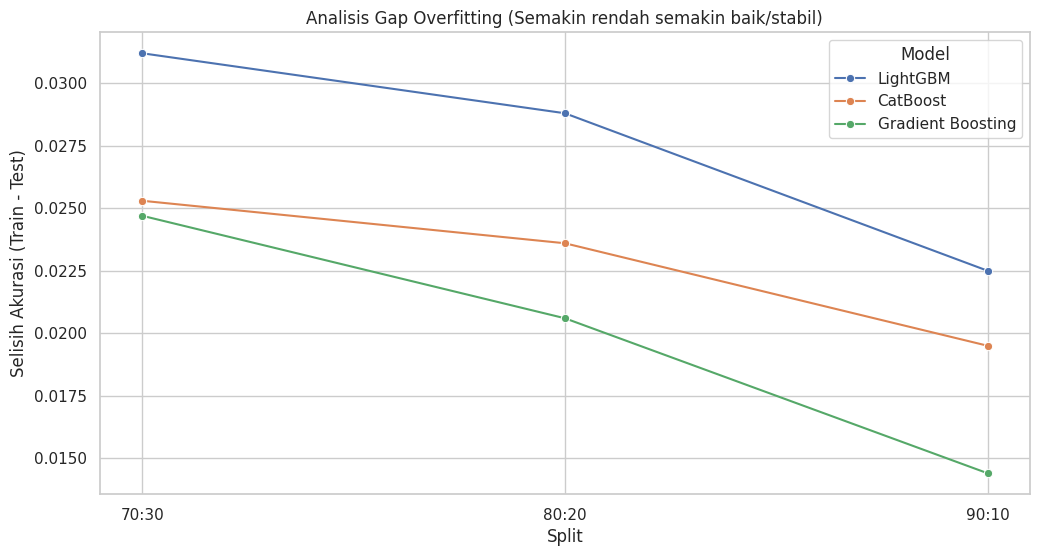

In [60]:
# Analisis Gap Overfitting (Train vs Test Accuracy)
df_results['Gap'] = abs(df_results['Train_Acc'] - df_results['Test_Acc'])
plt.figure(figsize=(12, 6))
sns.lineplot(x='Split', y='Gap', hue='Model', marker='o', data=df_results)
plt.title('Analisis Gap Overfitting (Semakin rendah semakin baik/stabil)')
plt.ylabel('Selisih Akurasi (Train - Test)')
plt.show()

# **Implementasi Model (INFERENCE)**
"Tahap inferensi menggunakan model LightGBM, CatBoost, atau Gradient Boosting untuk memprediksi risiko nasabah baru. Data diproses melalui StandardScaler agar konsisten dengan tahap pelatihan , menghasilkan status prediksi ( Aman/Gagal Bayar ) serta skor kemungkinan risikonya."

In [68]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML

# =========================================================
# 1. SETUP TAMPILAN (UI)
# =========================================================
title = widgets.HTML("<h1 style='text-align:center; color:#2c3e50; margin-bottom:0;'>Sistem Analisis Risiko Kredit</h1>")
subtitle = widgets.HTML("<p style='text-align:center; color:#7f8c8d; margin-top:0;'>Universitas Halu Oleo - Prediksi Kelayakan Pinjaman Nasabah</p>")

# Gaya untuk melebarkan area label (Agar teks tidak terpotong)
# Kita set lebarnya menjadi 150px
style_label = {'description_width': '150px'}
layout_input = {'width': '400px'} # Sedikit dilebarkan juga total width-nya

# Widgets Input - Data Demografi & Keuangan (TAMBAHKAN style=style_label)
age = widgets.IntSlider(description="Umur:", min=18, max=100, value=25, style=style_label, layout=layout_input)
income = widgets.FloatText(description="Pendapatan pertahun:", value=50000, style=style_label, layout=layout_input)
emp_length = widgets.FloatText(description="Lama Kerja (tahun):", value=5.0, style=style_label, layout=layout_input)
cred_len = widgets.IntSlider(description="Lama Kredit (tahun):", min=0, max=30, value=2, style=style_label, layout=layout_input)

# Widgets Input - Detail Pinjaman (TAMBAHKAN style=style_label)
amount = widgets.FloatText(description="Jumlah Pinjaman:", value=10000, style=style_label, layout=layout_input)
rate = widgets.FloatText(description="Suku Bunga (%):", value=11.0, style=style_label, layout=layout_input)
home = widgets.Dropdown(options=[('RENT', 0), ('OWN', 1), ('MORTGAGE', 2), ('OTHER', 3)], description="Status Kepemilikan Rumah:", style=style_label, layout=layout_input)
intent = widgets.Dropdown(options=[('PERSONAL', 0), ('EDUCATION', 1), ('MEDICAL', 2), ('VENTURE', 3), ('HOMEIMPROVEMENT', 4), ('DEBTCONSOLIDATION', 5)], description="Tujuan Pinjaman:", style=style_label, layout=layout_input)
default_hist = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description="Pernah Default (Gagal):", style=style_label, layout=layout_input)

input_box = widgets.VBox([
    widgets.HTML("<b style='color:#2980b9; font-size:16px;'><br>📋 Profil Nasabah & Pinjaman</b>"),
    age, income, emp_length, cred_len, amount, rate, home, intent, default_hist
], layout=widgets.Layout(padding='0 20px 20px 20px', border='1px solid #ddd', border_radius='15px', background_color='#fdfdfd'))

# Konfigurasi Model (Hanya Rasio Terbaik 90:10)
model_choice = widgets.Dropdown(
    options=[
        ("LightGBM (90:10)", "LightGBM"),
        ("CatBoost (90:10)", "CatBoost"),
        ("Gradient Boosting (90:10)", "Gradient Boosting")
    ],
    description="Pilih Model:", style=style_label, layout={'width': '350px'}
)

predict_btn = widgets.Button(description="Analisis Risiko", button_style='primary', icon='check', layout={'width': '170px', 'height': '45px'})
reset_btn = widgets.Button(description="Reset Data", button_style='warning', icon='refresh', layout={'width': '170px', 'height': '45px'})
output = widgets.Output()

btn_box = widgets.HBox([predict_btn, reset_btn], layout=widgets.Layout(gap='10px'))
control_box = widgets.VBox([
    widgets.HTML("<b style='color:#2980b9; font-size:16px;'><br>⚙️ Kontrol Panel</b>"),
    model_choice, btn_box,
    widgets.HTML("<br><b style='color:#2980b9; font-size:16px;'>📊 Hasil Penilaian</b>"),
    output
], layout=widgets.Layout(padding='10px'))

ui = widgets.HBox([input_box, control_box], layout=widgets.Layout(justify_content='center', gap='40px'))

# =========================================================
# 2. LOGIKA PREDIKSI
# =========================================================
def predict_fn(b):
    with output:
        output.clear_output()
        try:
            # A. Hitung Rasio Pinjaman
            p_income = amount.value / income.value if income.value > 0 else 0
            kolom_model = features_final.columns.tolist()
            final_df = pd.DataFrame(np.zeros((1, len(kolom_model))), columns=kolom_model)

            # B. Mapping data
            data_input = {
                'Age': age.value, 'Income': income.value, 'Home': home.value,
                'Emp_length': emp_length.value, 'Intent': intent.value,
                'Amount': amount.value, 'Rate': rate.value,
                'Percent_income': p_income, 'Default': default_hist.value,
                'Cred_length': cred_len.value
            }

            for col, val in data_input.items():
                if col in final_df.columns: final_df[col] = val
            if 'Id' in final_df.columns: final_df['Id'] = 0

            # C. Transform & Predict (Mengambil dari trained_models["90:10"])
            data_scaled = scaler.transform(final_df)
            final_input_ready = pd.DataFrame(data_scaled, columns=kolom_model)

            # Kunci utama: Selalu mengambil dari grup rasio 90:10
            model = trained_models["90:10"][model_choice.value]

            pred = model.predict(final_input_ready)
            prob = model.predict_proba(final_input_ready)
            risk_score = prob[0][1] * 100
            final_pred = pred.flatten()[0] if hasattr(pred, "flatten") else pred[0]

            # D. Tampilan Hasil
            if final_pred == 1:
                res_color, bg_light, res_text = "#e74c3c", "#FFF5F5", "🔴 RISIKO TINGGI: GAGAL BAYAR"
                sub_text = "Nasabah ini terindikasi memiliki profil risiko tinggi. Disarankan untuk menolak permohonan kredit."
            else:
                res_color, bg_light, res_text = "#27ae60", "#F0FFF4", "🟢 STATUS: AMAN / LAYAK"
                sub_text = "Profil risiko nasabah ini rendah. Permohonan kredit layak untuk diproses lebih lanjut."

            meter_html = f"""
            <div style="width: 100%; background-color: #e0e0e0; border-radius: 20px; height: 25px; margin: 15px 0;">
                <div style="width: {risk_score:.2f}%; background-color: {res_color}; border-radius: 20px; height: 100%; transition: width 0.8s ease-in-out;">
                    <span style="color: white; font-weight: bold; padding-left: 10px; line-height: 25px; font-size: 12px;">{risk_score:.2f}%</span>
                </div>
            </div>
            """

            display(HTML(f"""
                <div style='background-color:{bg_light}; padding:20px; border-radius:15px; border: 3px solid {res_color}; font-family: sans-serif; width:350px;'>
                    <h3 style='margin:0; color:{res_color}; text-align:center;'>{res_text}</h3>
                    {meter_html}
                    <p style='text-align:justify; color:#333; font-size:13px; line-height:1.4;'>{sub_text}</p>
                    <div style='display: flex; justify-content: space-between; font-size: 11px; color: #666; margin-top:10px; border-top:1px solid #ddd; padding-top:10px;'>
                        <span>Model: <b>{model_choice.value}</b></span>
                        <span>Keputusan: <b>{'TOLAK' if final_pred == 1 else 'SETUJUI'}</b></span>
                    </div>
                </div>
            """))
        except Exception as e:
            display(HTML(f"<div style='color:red;'><b>Error:</b> {str(e)}</div>"))

def reset_fn(b):
    age.value, income.value, emp_length.value, cred_len.value = 25, 50000, 5.0, 2
    amount.value, rate.value, home.value, intent.value, default_hist.value = 10000, 11.0, 0, 0, 0
    with output: output.clear_output()

predict_btn.on_click(predict_fn)
reset_btn.on_click(reset_fn)

# Tampilkan UI
display(title, subtitle, ui)

HTML(value="<h1 style='text-align:center; color:#2c3e50; margin-bottom:0;'>Sistem Analisis Risiko Kredit</h1>"…

HTML(value="<p style='text-align:center; color:#7f8c8d; margin-top:0;'>Universitas Halu Oleo - Prediksi Kelaya…